In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error

In [2]:
df = datasets.load_diabetes(as_frame=True).frame

In [4]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [5]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [6]:
x = df.drop("target",axis=1)
y = df["target"]

In [25]:
from sklearn.preprocessing import StandardScaler
sclr = StandardScaler()

y = sclr.fit_transform(y.values.reshape(-1,1)).ravel()

In [26]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,random_state=12
)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

params = {
    "max_depth":[2,3,4,5,6],
    "min_samples_leaf":[10,20,30,40]
}

grid = GridSearchCV(DecisionTreeRegressor(), params, cv=5)

grid.fit(x_train,y_train)

print(grid.best_params_)

{'max_depth': 3, 'min_samples_leaf': 20}


In [28]:
d_reg = DecisionTreeRegressor(max_depth=3,min_samples_leaf=20)
d_reg.fit(x_train,y_train)
y_pred = d_reg.predict(x_test)
acc = r2_score(y_test,y_pred)
print("best score : ", acc)    


best score :  0.29696779319961275


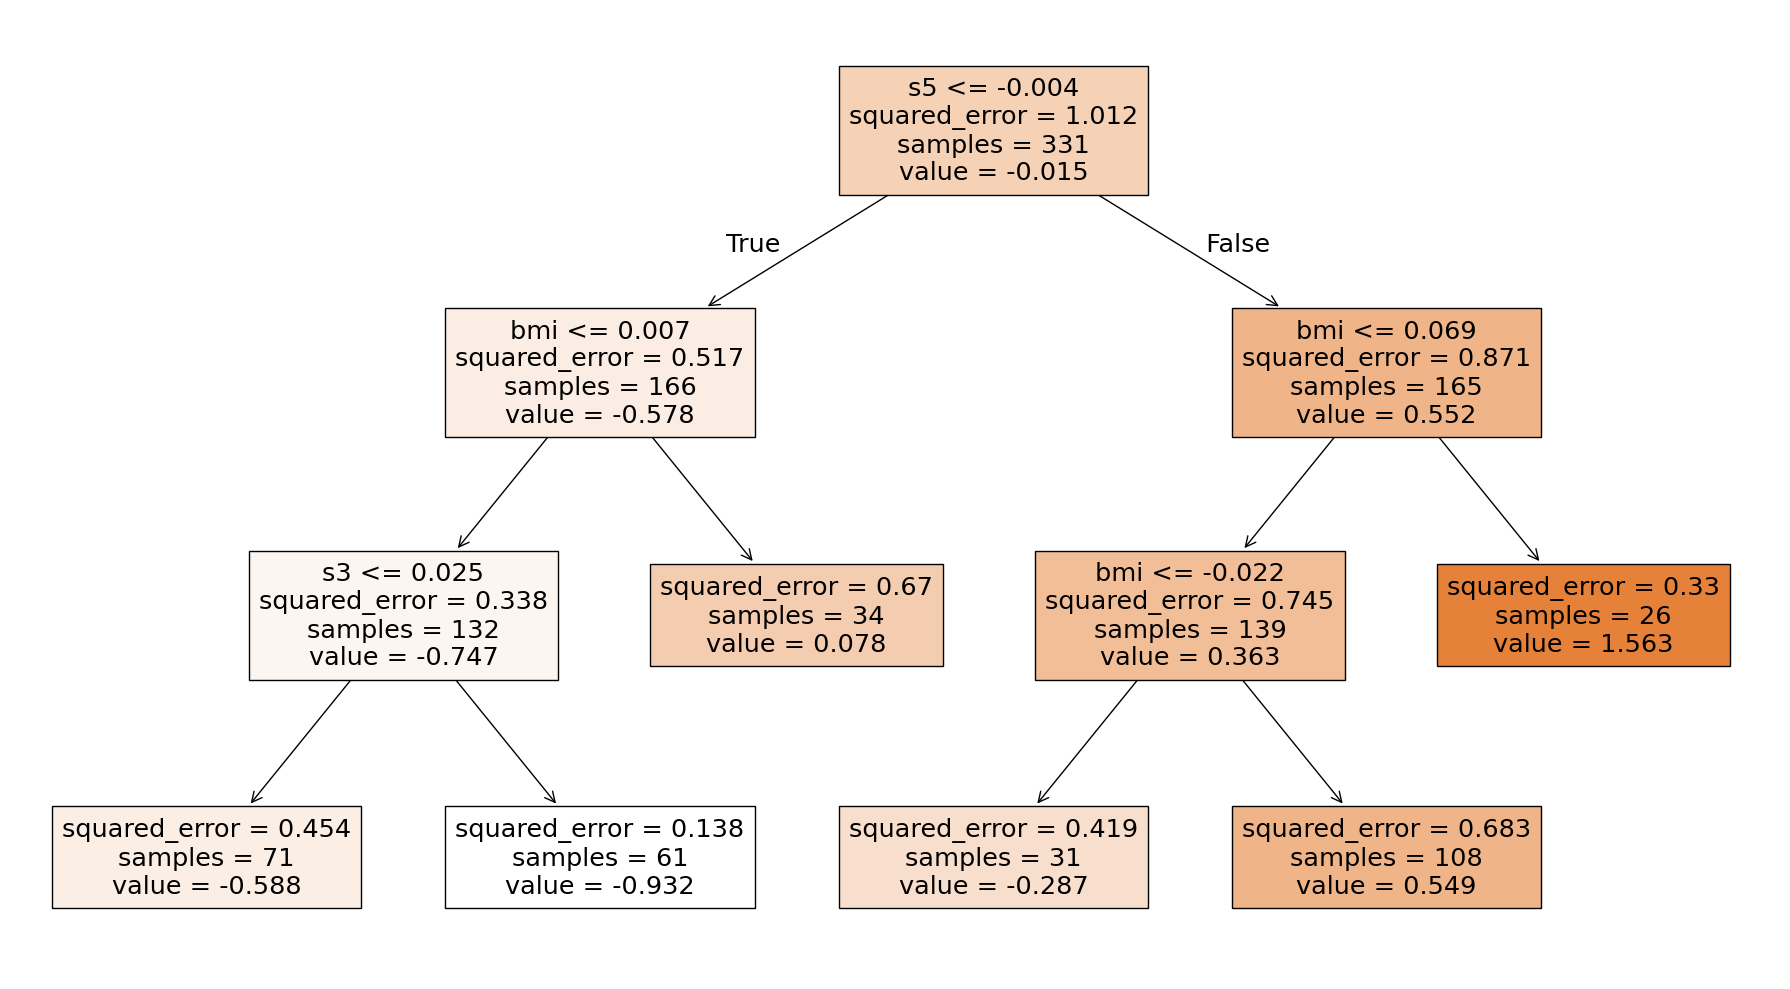

In [29]:
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    d_reg,
    feature_names=x.columns,
    filled=True
)

plt.tight_layout()